# Building Height Estimation from Temporal Presence

**Objective:** predict building height (metres) from the 7-year presence history (2016–2022).

**Three-model ablation — each adds exactly one component:**

| Model | Input | DL component |
|---|---|---|
| Mean baseline | — | None — predicts training mean |
| Single-year UNet | 2022 presence only | Spatial encoder-decoder |
| Multi-year UNet | 2016–2022 presence | Adds temporal context |
| Temporal attention UNet | 2016–2022 presence | Adds learned year weighting |

**Key questions answered by this notebook:**
1. Is predicting height from presence feasible at all? (single-year vs mean baseline)
2. Does temporal history carry extra signal? (multi-year vs single-year)
3. Does attention use temporal context intelligently? (attention vs multi-year)

Patches are reused from the growth notebook. **Known limitation:** growth-biased sampling (70 % growth patches) underrepresents dense urban cores where tall buildings concentrate. Future iteration: re-sample with only a minimum built-share criterion.

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from rasterio.enums import Resampling
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from shapely.geometry import box
from torch.utils.data import DataLoader, Dataset

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR    = PROJECT_DIR / "data" / "processed" / "open_buildings_temporal"
CACHE_DIR   = PROJECT_DIR / "data" / "cache"     / "open_buildings_temporal"
MODEL_DIR   = PROJECT_DIR / "models"             / "open_buildings_temporal"
PATCH_SIZE  = 128
CITY_IMAGE_SIZE = 1024
HALF_DEG    = 0.02

device = torch.device(
    "mps"  if (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()) else
    "cuda" if torch.cuda.is_available() else "cpu"
)

GROWTH_PATH   = sorted(DATA_DIR.glob("patches_*.npz"),    key=lambda p: p.stat().st_mtime)[-1]
HASH          = GROWTH_PATH.stem.split("_", 1)[1]
HEIGHT_PATH   = DATA_DIR / f"height_patches_{HASH}.npz"
METADATA_PATH = DATA_DIR / f"metadata_{HASH}.json"

AOI_CENTERS = {
    "new_cairo":    [30.0115,  31.5499], "accra":       [ 5.6037,  -0.1870],
    "nairobi":      [-1.2864,  36.8172], "lagos":       [ 6.5244,   3.3792],
    "addis_ababa":  [ 8.9806,  38.7578], "dhaka":       [23.8103,  90.4125],
    "delhi":        [28.6139,  77.2090], "karachi":     [24.8607,  67.0011],
    "chennai":      [13.0827,  80.2707], "jakarta":     [-6.2088, 106.8456],
    "ho_chi_minh":  [10.8231, 106.6297], "lima":        [-12.046, -77.0428],
    "bogota":       [ 4.7110, -74.0721], "quito":       [-0.1807, -78.4678],
    "medellin":     [ 6.2442, -75.5812], "manila":      [14.5995, 120.9842],
    "phnom_penh":   [11.5564, 104.9282], "kampala":     [ 0.3476,  32.5825],
    "kigali":       [-1.9441,  30.0619], "bangkok":     [13.7563, 100.5018],
    "mexico_city":  [19.4326, -99.1332], "sao_paulo":   [-23.550, -46.6333],
    "dar_es_salaam":[-6.7924,  39.2083], "lahore":      [31.5204,  74.3587],
    "hanoi":        [21.0278, 105.8342],
}
AOI_BOXES = {
    c: box(lon - HALF_DEG, lat - HALF_DEG, lon + HALF_DEG, lat + HALF_DEG)
    for c, (lat, lon) in AOI_CENTERS.items()
}
tile_index = pd.read_csv(
    sorted(CACHE_DIR.glob("tile_index_*.csv"), key=lambda p: p.stat().st_mtime)[-1]
)


def _read_aoi(url, aoi, band):
    fb = {"building_fractional_count": 1, "building_height": 2, "building_presence": 3}
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        with rasterio.open(url) as src:
            mnx, mny, mxx, mxy = transform_bounds("EPSG:4326", src.crs, *aoi.bounds, densify_pts=21)
            win = from_bounds(mnx, mny, mxx, mxy, src.transform).round_offsets().round_lengths()
            desc = [d or "" for d in src.descriptions]
            bi = next(
                (i + 1 for i, d in enumerate(desc) if band in d.lower()),
                min(fb.get(band, 1), src.count),
            )
            arr = src.read(
                bi, window=win, out_shape=(CITY_IMAGE_SIZE, CITY_IMAGE_SIZE),
                resampling=Resampling.bilinear, boundless=True, fill_value=0,
            ).astype(np.float32)
    return np.where(arr < 0, 0.0, np.nan_to_num(arr))


def read_city_band(city_name, year, band):
    urls = tile_index.loc[
        (tile_index["city"] == city_name) & (tile_index["year"] == year), "url"
    ].tolist()
    arrays = []
    for url in urls:
        try:
            arrays.append(_read_aoi(url, AOI_BOXES[city_name], band))
        except Exception:
            pass
    if not arrays:
        raise ValueError(f"No tiles for {city_name} {year}")
    return np.maximum.reduce(arrays)


print(f"Device: {device}")
print(f"Reusing growth patches: {GROWTH_PATH.name}  ({HASH})")

Device: mps
Reusing growth patches: patches_e01f59a7c1.npz  (e01f59a7c1)


Load the presence patches and extract 2022 height at the same patch locations. One city image is downloaded per city, not one per patch.

In [5]:
data      = np.load(GROWTH_PATH, allow_pickle=True)
x         = data["x"]      # (N, 7, H, W) uint8 — presence 2016–2022
city_arr  = data["city"]   # (N,) city name per patch
split_arr = data["split"]  # (N,) 'train' / 'val' / 'test'
metadata  = json.loads(METADATA_PATH.read_text())

if HEIGHT_PATH.exists():
    h_raw = np.load(HEIGHT_PATH)["height"]  # (N, 1, H, W) float32 metres
    print(f"Height patches loaded from cache: {h_raw.shape}")
else:
    print("Extracting height patches (one city image download per city)...")
    city_imgs = {}
    for c in np.unique(city_arr):
        print(f"  {c}", end=" ", flush=True)
        city_imgs[c] = read_city_band(c, 2022, "building_height")
    print()
    patches = []
    for m in metadata:
        r, col = m["row"], m["col"]
        patches.append(city_imgs[m["city"]][r : r + PATCH_SIZE, col : col + PATCH_SIZE])
    h_raw = np.stack(patches)[:, np.newaxis].astype(np.float32)  # (N, 1, H, W)
    np.savez_compressed(HEIGHT_PATH, height=h_raw)
    print(f"Saved: {HEIGHT_PATH.name}  shape={h_raw.shape}")

train_idx = np.where(split_arr == "train")[0]
val_idx   = np.where(split_arr == "val")[0]
test_idx  = np.where(split_arr == "test")[0]

built_train   = x[train_idx, -1] >= 128
h_train_built = h_raw[train_idx, 0][built_train]
MEAN_LOG_H    = float(np.log1p(h_train_built).mean())  # used as mean-baseline prediction

print(f"\nSplit — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")
print(f"Training built pixels: {built_train.sum():,}")
print(f"Height on built pixels — median: {np.median(h_train_built):.1f} m  "
      f"p90: {np.percentile(h_train_built, 90):.1f} m  max: {h_train_built.max():.1f} m")

Height patches loaded from cache: (2472, 1, 128, 128)

Split — train: 1542  val: 480  test: 450
Training built pixels: 5,961,348
Height on built pixels — median: 7.0 m  p90: 16.5 m  max: 98.9 m


Quick alignment check: rows are training patches selected for having high maximum height (most informative to visualise).

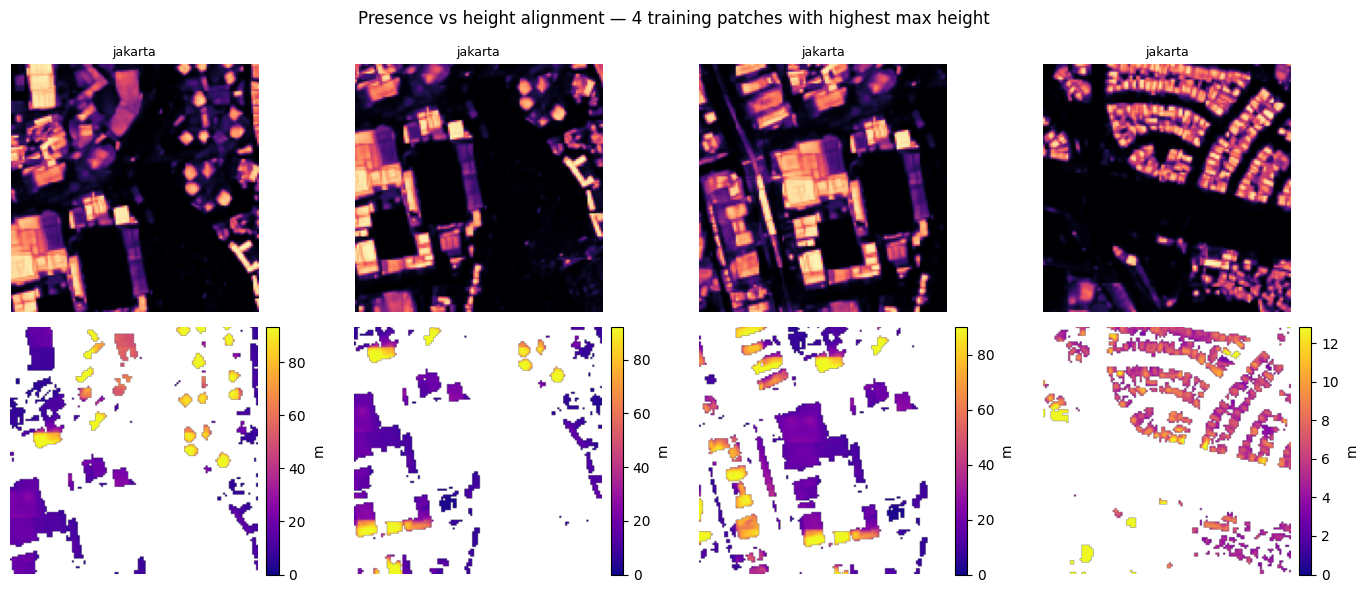

In [6]:
high_h_idx = train_idx[np.argsort(h_raw[train_idx, 0].max(axis=(1, 2)))[-4:]]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for col, idx in enumerate(high_h_idx):
    built  = x[idx, -1] >= 128
    height = h_raw[idx, 0]
    vmax   = np.percentile(height[built], 95) if built.any() else 20

    axes[0, col].imshow(x[idx, -1], cmap="magma", vmin=0, vmax=255)
    axes[0, col].set_title(f"{city_arr[idx]}", fontsize=9)
    axes[0, col].axis("off")

    im = axes[1, col].imshow(
        np.where(built, height, np.nan), cmap="plasma", vmin=0, vmax=vmax
    )
    axes[1, col].axis("off")
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.03, label="m")

axes[0, 0].set_ylabel("2022 presence", fontsize=9)
axes[1, 0].set_ylabel("2022 height (m)", fontsize=9)
plt.suptitle("Presence vs height alignment — 4 training patches with highest max height")
plt.tight_layout()
plt.show()

Model definitions. `HeightUNet` covers all three variants via `in_ch` and `attention` flags.

In [7]:
class TemporalAttention(nn.Module):
    """Squeeze-and-excitation over the temporal (year) axis.
    Learns which years are most informative for height prediction.
    Scale-preserving: uniform weights leave the input unchanged."""
    def __init__(self, n_ch):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(n_ch, n_ch)

    def forward(self, x):
        w = torch.softmax(self.fc(self.pool(x).flatten(1)), dim=1)
        return x * w.unsqueeze(-1).unsqueeze(-1) * x.size(1)

    def mean_weights(self, x):
        """Return per-year attention weights averaged over the batch."""
        with torch.no_grad():
            return torch.softmax(self.fc(self.pool(x).flatten(1)), dim=1).mean(0).cpu().numpy()


class _ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class HeightUNet(nn.Module):
    def __init__(self, in_ch, base=16, attention=False):
        super().__init__()
        self.in_ch = in_ch
        self.att   = TemporalAttention(in_ch) if attention else None
        self.e1    = _ConvBlock(in_ch, base)
        self.e2    = _ConvBlock(base, base * 2)
        self.bn    = _ConvBlock(base * 2, base * 4)
        self.u2    = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.d2    = _ConvBlock(base * 4, base * 2)
        self.u1    = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.d1    = _ConvBlock(base * 2, base)
        self.out   = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        if self.att is not None:
            x = self.att(x)
        e1 = self.e1(x)
        e2 = self.e2(F.max_pool2d(e1, 2))
        b  = self.bn(F.max_pool2d(e2, 2))
        d2 = self.d2(torch.cat([self.u2(b), e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)


MODEL_SPECS = [
    {"name": "single_year",  "label": "Single-year",       "in_ch": 1, "attention": False},
    {"name": "multi_year",   "label": "Multi-year",        "in_ch": 7, "attention": False},
    {"name": "temporal_att", "label": "Temporal attention", "in_ch": 7, "attention": True},
]
for spec in MODEL_SPECS:
    spec["path"] = MODEL_DIR / f"height_{spec['name']}_{HASH}.pt"
    spec["n_params"] = sum(p.numel() for p in HeightUNet(spec["in_ch"], attention=spec["attention"]).parameters())

print(pd.DataFrame([{"model": s["label"], "in_ch": s["in_ch"],
                      "attention": s["attention"], "params": s["n_params"]} for s in MODEL_SPECS]).to_string(index=False))

             model  in_ch  attention  params
       Single-year      1      False  117393
        Multi-year      7      False  118257
Temporal attention      7       True  118313


Train all three models (or load from disk if already saved). Target is `log1p(height)` on built pixels; Huber loss is robust to the rare tall-building outliers.

Loaded:   Single-year
Loaded:   Multi-year
Loaded:   Temporal attention


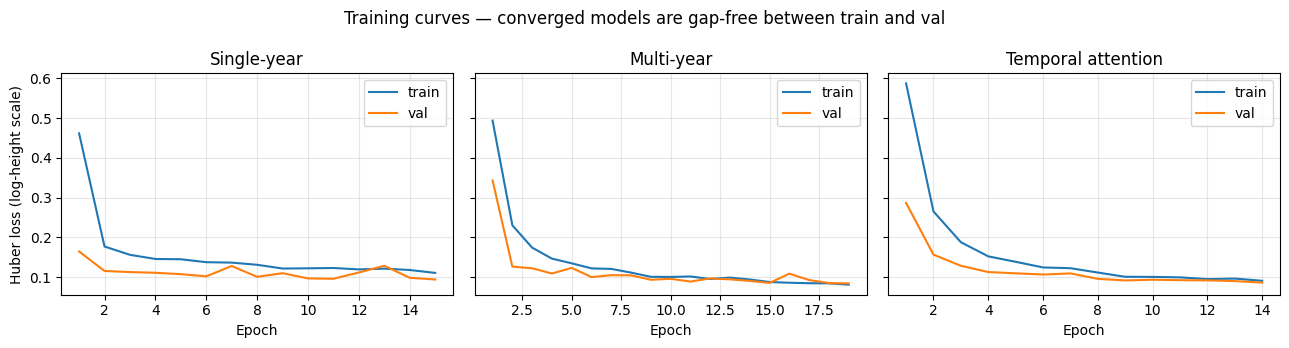

In [8]:
EPOCHS   = 25
PATIENCE = 5
BASE_CH  = 16


class HeightDataset(Dataset):
    def __init__(self, indices):
        self.idx = indices

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j    = int(self.idx[i])
        pres = torch.from_numpy(x[j].astype(np.float32) / 255.0)              # (7, H, W)
        h    = torch.from_numpy(np.log1p(h_raw[j]).astype(np.float32))        # (1, H, W) log-scale
        mask = torch.from_numpy((x[j, -1] >= 128).astype(np.float32))[None]   # (1, H, W) built pixels
        return pres, h, mask


def _run_epoch(model, dl, in_ch, opt=None):
    model.train(opt is not None)
    losses = []
    for pres, h, mask in dl:
        x_in = (pres[:, -1:] if in_ch == 1 else pres).to(device)
        h, mask = h.to(device), mask.to(device).bool()
        if not mask.any():
            continue
        pred = model(x_in)
        loss = F.huber_loss(pred[mask], h[mask], delta=1.0)
        if opt is not None:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0


def train_or_load(spec):
    if spec["path"].exists():
        ckpt  = torch.load(spec["path"], map_location=device, weights_only=False)
        model = HeightUNet(spec["in_ch"], BASE_CH, spec["attention"]).to(device)
        model.load_state_dict(ckpt["state"])
        model.eval()
        print(f"Loaded:   {spec['label']}")
        return model, ckpt["history"]

    torch.manual_seed(SEED)
    model = HeightUNet(spec["in_ch"], BASE_CH, spec["attention"]).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=2)
    dl_tr = DataLoader(HeightDataset(train_idx), 32, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED))
    dl_vl = DataLoader(HeightDataset(val_idx),   32, shuffle=False)

    print(f"Training: {spec['label']}")
    history, best_loss, stalls = [], float("inf"), 0
    for epoch in range(1, EPOCHS + 1):
        tr = _run_epoch(model, dl_tr, spec["in_ch"], opt)
        vl = _run_epoch(model, dl_vl, spec["in_ch"])
        sched.step(vl)
        history.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 5 == 0:
            print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
        if vl < best_loss - 1e-4:
            best_loss, stalls = vl, 0
            torch.save({"state": model.state_dict(), "history": history}, spec["path"])
        else:
            stalls += 1
            if stalls >= PATIENCE:
                print(f"  Early stop at epoch {epoch}.")
                break
    best = min(history, key=lambda r: r["val"])
    print(f"  Best epoch: {best['epoch']:02d} | train {best['train']:.4f} | val {best['val']:.4f}")
    model.load_state_dict(torch.load(spec["path"], map_location=device, weights_only=False)["state"])
    model.eval()
    return model, history


trained, histories = {}, {}
for spec in MODEL_SPECS:
    trained[spec["name"]], histories[spec["name"]] = train_or_load(spec)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, spec in zip(axes, MODEL_SPECS):
    df = pd.DataFrame(histories[spec["name"]])
    ax.plot(df["epoch"], df["train"], label="train")
    ax.plot(df["epoch"], df["val"],   label="val")
    ax.set_title(spec["label"])
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Huber loss (log-height scale)")
plt.suptitle("Training curves — converged models are gap-free between train and val")
plt.tight_layout()
plt.show()

Evaluate all models on the held-out test cities. MAE is in original metres (after inverting log transform).

MODELS
──────────────────────────────────────────────────────────────────────
  Name                        What it uses as input               Params
──────────────────────────────────────────────────────────────────────
  Mean baseline               nothing — predicts 7 m for every building  —
  Single-year                 2022 building presence  (1 binary channel)  117,393
  Multi-year                  2016–2022 presence  (7 channels, all years)  118,257
  Temporal attention          2016–2022 presence + learned year weighting  118,313
──────────────────────────────────────────────────────────────────────

TEST RESULTS  —  450 patches, 5 held-out cities
MAE = mean absolute error in metres.  vs baseline = improvement over the no-learning baseline.
Positive % = better than baseline.  Negative % = worse than baseline.
──────────────────────────────────────────────────────────────────────
  Model                                        MAE (m)    RMSE (m)   vs baseline
──────────────────

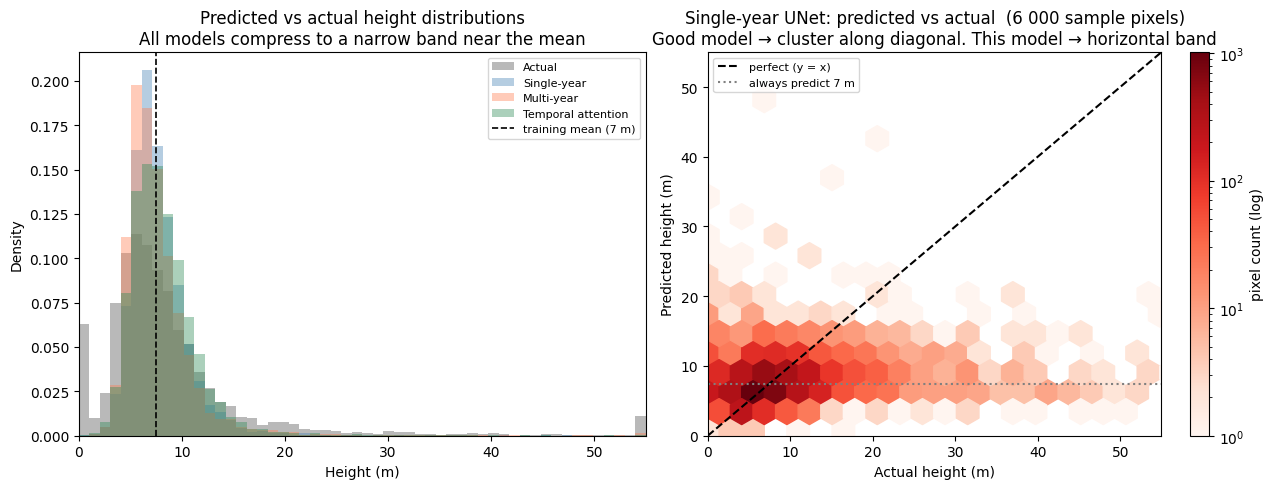

In [9]:
def _predict(model, indices, in_ch):
    dl = DataLoader(HeightDataset(indices), 64, shuffle=False)
    preds, trues, masks = [], [], []
    model.eval()
    with torch.no_grad():
        for pres, h, mask in dl:
            x_in = (pres[:, -1:] if in_ch == 1 else pres).to(device)
            preds.append(model(x_in).cpu().numpy())
            trues.append(h.numpy())
            masks.append(mask.numpy() >= 0.5)
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(masks)


def _score(pred_log, true_log, built, label, base_mae=None):
    pm   = np.expm1(np.maximum(pred_log[built], 0.0))
    tm   = np.expm1(true_log[built])
    mae  = round(float(np.abs(pm - tm).mean()), 2)
    rmse = round(float(np.sqrt(((pm - tm) ** 2).mean())), 2)
    vs   = f"{100 * (base_mae - mae) / base_mae:+.1f} %" if base_mae else "—"
    rows = []
    for name, lo, hi in [("<5 m", 0, 5), ("5–15 m", 5, 15), ("15–30 m", 15, 30), (">30 m", 30, 400)]:
        m = (tm >= lo) & (tm < hi)
        if m.sum() > 10:
            rows.append({"range": name, "pixels": int(m.sum()),
                         "%": f"{100 * m.mean():.0f}",
                         "MAE (m)": round(float(np.abs(pm[m] - tm[m]).mean()), 2)})
    return {"model": label, "MAE (m)": mae, "RMSE (m)": rmse, "vs mean baseline": vs}, pd.DataFrame(rows)


test_true  = np.log1p(h_raw[test_idx]).astype(np.float32)
test_built = (x[test_idx, -1] >= 128)[:, np.newaxis]
base_pred  = np.full_like(test_true, MEAN_LOG_H)
base_row, _ = _score(base_pred, test_true, test_built, "Mean baseline  (predict training mean everywhere)")
base_mae   = base_row["MAE (m)"]

all_preds = {}
results, bucket_tbls = [base_row], {}
for spec in MODEL_SPECS:
    pred, true, built = _predict(trained[spec["name"]], test_idx, spec["in_ch"])
    row, bt = _score(pred, true, built, spec["label"], base_mae)
    results.append(row)
    bucket_tbls[spec["label"]] = bt
    all_preds[spec["name"]] = pred

SEP = "─" * 70

# ── What each model is ──────────────────────────────────────────────────────
print("MODELS")
print(SEP)
print(f"  {'Name':<26}  {'What it uses as input':<34}  Params")
print(SEP)
descriptions = [
    ("Mean baseline",          "nothing — predicts 7 m for every building",   "—"),
    ("Single-year",            "2022 building presence  (1 binary channel)",   f"{MODEL_SPECS[0]['n_params']:,}"),
    ("Multi-year",             "2016–2022 presence  (7 channels, all years)",  f"{MODEL_SPECS[1]['n_params']:,}"),
    ("Temporal attention",     "2016–2022 presence + learned year weighting",  f"{MODEL_SPECS[2]['n_params']:,}"),
]
for name, desc, p in descriptions:
    print(f"  {name:<26}  {desc:<34}  {p}")
print(SEP)
print()

# ── Results ─────────────────────────────────────────────────────────────────
best_label = min(results[1:], key=lambda r: r["MAE (m)"])["model"]
best_mae_v = next(r["MAE (m)"] for r in results if r["model"] == best_label)

print(f"TEST RESULTS  —  {len(test_idx)} patches, 5 held-out cities")
print(f"MAE = mean absolute error in metres.  vs baseline = improvement over the no-learning baseline.")
print(f"Positive % = better than baseline.  Negative % = worse than baseline.")
print(SEP)
print(f"  {'Model':<42}  {'MAE (m)':>8}  {'RMSE (m)':>10}  {'vs baseline':>12}")
print(SEP)
for r in results:
    tag = "  ← best DL model" if r["model"] == best_label else ""
    print(f"  {r['model']:<42}  {r['MAE (m)']:>8.2f}  {r['RMSE (m)']:>10.2f}  {r['vs mean baseline']:>12}{tag}")
print(SEP)
print(f"  The best DL model ({best_label}) cuts MAE by {base_mae - best_mae_v:.2f} m ({100*(base_mae-best_mae_v)/base_mae:.1f} %)")
print(f"  over simply predicting 7 m everywhere. Adding temporal years (Multi-year, Temporal attention)")
print(f"  does not help — both are slightly worse than the 1-channel model.")
print()

# ── Per-bucket breakdown ─────────────────────────────────────────────────────
print(f"WHERE DOES THE BEST MODEL FAIL?  ({best_label}  —  per height bucket)")
print(SEP)
print(bucket_tbls[best_label].to_string(index=False))
print(SEP)
print("  5–15 m (62 % of pixels): acceptable.  >30 m (3 % of pixels): completely unreliable.")
print()

# ── Diagnostic plots ─────────────────────────────────────────────────────────
rng_plt = np.random.default_rng(SEED)
flat_built = np.flatnonzero(test_built.ravel())
sidx = rng_plt.choice(flat_built, min(6000, len(flat_built)), replace=False)
actual_s = np.expm1(test_true.ravel()[sidx])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: height distribution — shows the "collapse to mean" problem
bins = np.linspace(0, 55, 55)
axes[0].hist(np.clip(actual_s, 0, 55), bins=bins, density=True, alpha=0.55, color="gray", label="Actual")
for spec, color in zip(MODEL_SPECS, ["steelblue", "coral", "seagreen"]):
    ps = np.expm1(np.maximum(all_preds[spec["name"]].ravel()[sidx], 0))
    axes[0].hist(np.clip(ps, 0, 55), bins=bins, density=True, alpha=0.4, color=color, label=spec["label"])
axes[0].axvline(np.expm1(MEAN_LOG_H), color="black", linestyle="--", lw=1.2,
                label=f"training mean ({np.expm1(MEAN_LOG_H):.0f} m)")
axes[0].set(xlabel="Height (m)", ylabel="Density", xlim=(0, 55))
axes[0].set_title("Predicted vs actual height distributions\nAll models compress to a narrow band near the mean")
axes[0].legend(fontsize=8)

# Right: scatter of best model — shows predictions are nearly flat regardless of actual height
ps_best = np.expm1(np.maximum(all_preds["single_year"].ravel()[sidx], 0))
hb = axes[1].hexbin(actual_s, ps_best, gridsize=35, mincnt=1, cmap="Reds", bins="log")
axes[1].plot([0, 55], [0, 55], "k--", lw=1.5, label="perfect (y = x)")
axes[1].axhline(np.expm1(MEAN_LOG_H), color="gray", ls=":", lw=1.5,
                label=f"always predict {np.expm1(MEAN_LOG_H):.0f} m")
axes[1].set(xlim=(0, 55), ylim=(0, 55), xlabel="Actual height (m)", ylabel="Predicted height (m)")
axes[1].set_title("Single-year UNet: predicted vs actual  (6 000 sample pixels)\nGood model → cluster along diagonal. This model → horizontal band")
axes[1].legend(fontsize=8)
plt.colorbar(hb, ax=axes[1], label="pixel count (log)")

plt.tight_layout()
plt.show()

Visual comparison: one patch per test city, chosen for having the highest height variance (most informative). All height maps use the same per-row colour scale.

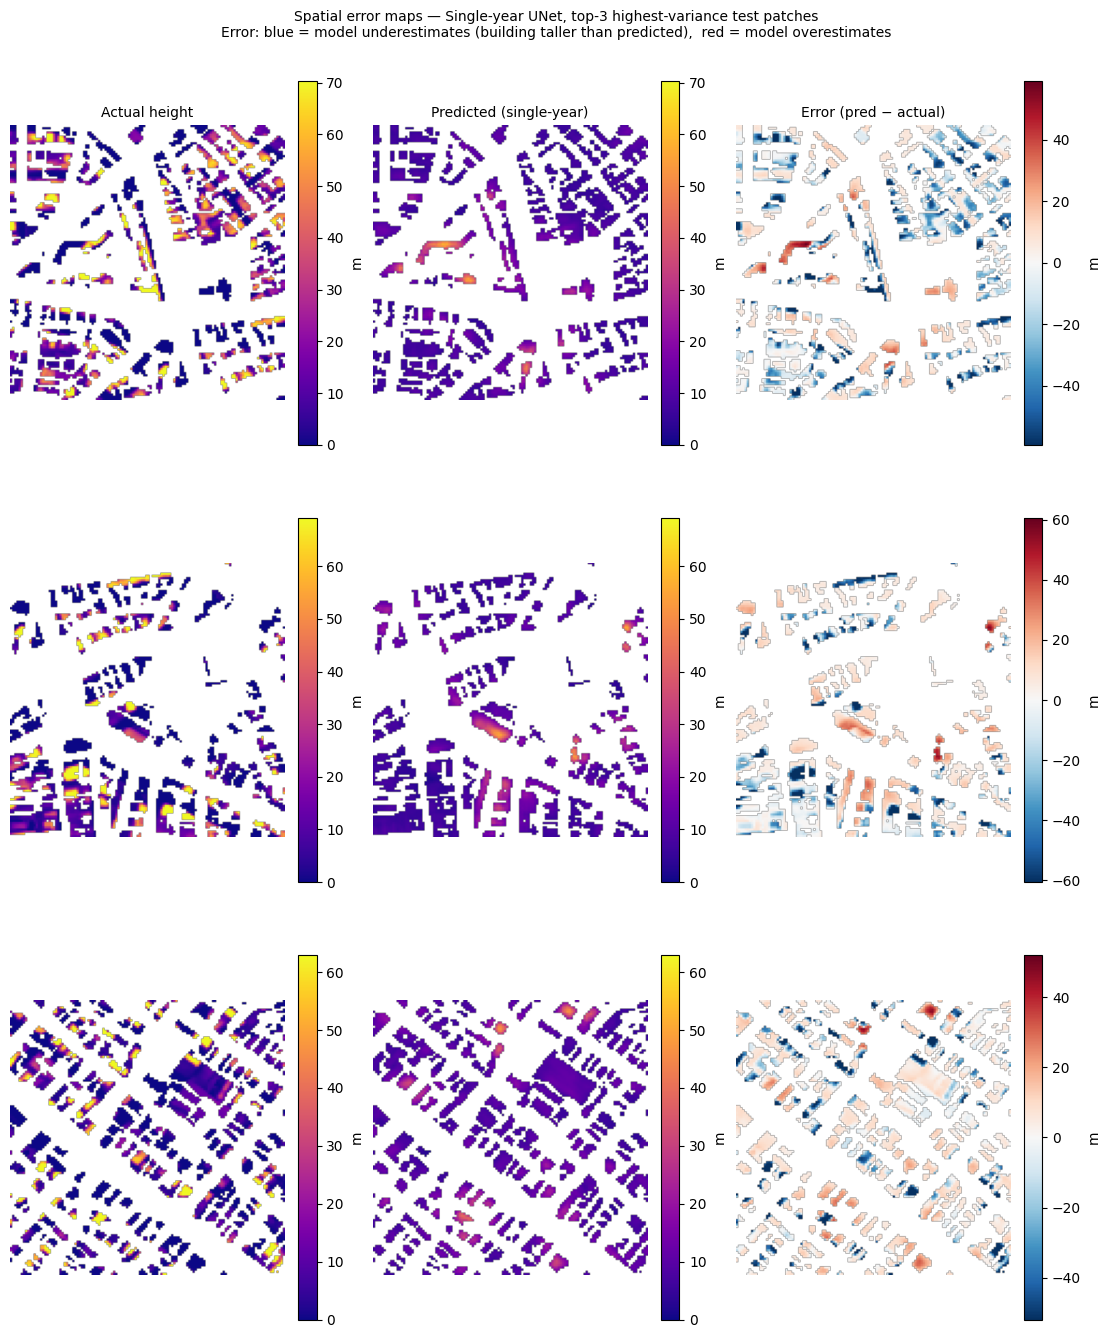

In [10]:
vis_indices = test_idx[np.argsort(h_raw[test_idx, 0].var(axis=(1, 2)))[-3:][::-1]]
pred_1yr, _, _ = _predict(trained["single_year"], vis_indices, in_ch=1)

n = len(vis_indices)
fig, axes = plt.subplots(n, 3, figsize=(11, 4.5 * n), constrained_layout=True)
if n == 1:
    axes = axes[np.newaxis]

for row, idx in enumerate(vis_indices):
    built  = x[idx, -1] >= 128
    actual = h_raw[idx, 0]
    pred   = np.expm1(np.maximum(pred_1yr[row, 0], 0.0))
    error  = np.where(built, pred - actual, np.nan)   # + = overestimate, − = underestimate
    vmax   = max(float(np.percentile(actual[built], 95)) if built.any() else 20, 5)
    emax   = max(float(np.nanpercentile(np.abs(error), 95)), 5)

    im0 = axes[row, 0].imshow(np.where(built, actual, np.nan), cmap="plasma", vmin=0, vmax=vmax)
    im1 = axes[row, 1].imshow(np.where(built, pred,   np.nan), cmap="plasma", vmin=0, vmax=vmax)
    im2 = axes[row, 2].imshow(error, cmap="RdBu_r", vmin=-emax, vmax=emax)

    for col, (ax, im, lbl) in enumerate(
        [(axes[row, 0], im0, "m"), (axes[row, 1], im1, "m"), (axes[row, 2], im2, "m")]
    ):
        ax.axis("off")
        if row == 0:
            ax.set_title(["Actual height", "Predicted (single-year)", "Error (pred − actual)"][col], fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.85, label=lbl)

    axes[row, 0].set_ylabel(city_arr[idx], fontsize=9)

plt.suptitle(
    "Spatial error maps — Single-year UNet, top-3 highest-variance test patches\n"
    "Error: blue = model underestimates (building taller than predicted),  red = model overestimates",
    fontsize=10,
)
plt.show()

Attention weight chart: which years does the temporal attention model focus on? Bars above the dashed line = weighted above uniform; below = less informative to the model.

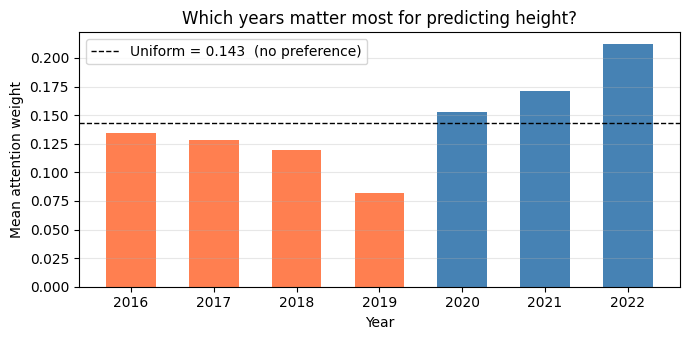

Blue = weighted above uniform  |  Red = below
If recent years dominate  → presence recency predicts height (newer ≠ taller, or newly built = shorter)
If early years dominate   → long-established presence predicts height (older areas = taller)
If all bars near uniform  → model finds no meaningful temporal ordering
  2016: 0.1343  (▼)
  2017: 0.1283  (▼)
  2018: 0.1196  (▼)
  2019: 0.0817  (▼)
  2020: 0.1530  (▲)
  2021: 0.1714  (▲)
  2022: 0.2118  (▲)


In [11]:
dl_test = DataLoader(HeightDataset(test_idx), 64, shuffle=False)
att_model = trained["temporal_att"]
att_model.eval()

batch_weights = []
with torch.no_grad():
    for pres, _, _ in dl_test:
        batch_weights.append(att_model.att.mean_weights(pres.to(device)))
mean_w   = np.stack(batch_weights).mean(0)
years    = list(range(2016, 2023))
uniform  = 1.0 / len(years)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["steelblue" if w >= uniform else "coral" for w in mean_w]
ax.bar(years, mean_w, color=colors, width=0.6)
ax.axhline(uniform, color="black", linestyle="--", linewidth=1,
           label=f"Uniform = {uniform:.3f}  (no preference)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean attention weight")
ax.set_title("Which years matter most for predicting height?")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Blue = weighted above uniform  |  Red = below")
print("If recent years dominate  → presence recency predicts height (newer ≠ taller, or newly built = shorter)")
print("If early years dominate   → long-established presence predicts height (older areas = taller)")
print("If all bars near uniform  → model finds no meaningful temporal ordering")
for yr, w in zip(years, mean_w):
    print(f"  {yr}: {w:.4f}  ({'▲' if w >= uniform else '▼'})")

## Option B: Diverse Patch Sampling

The growth-biased patches (70% growth requirement) produced training data dominated by urban-fringe low-rise areas. This likely explains why the model can't learn tall buildings. This section re-samples without the growth requirement — patches just need ≥ 15% built area. That pulls in dense city-centre areas where height varies more.

**What this tests:** if the diverse-trained model improves on the >30m bucket, the data sampling was the bottleneck. If it doesn't, the task design is the problem (presence alone can't predict height).

| Model | Test MAE | vs mean baseline |
|---|---|---|
| Mean baseline | — | — |
| Single-year UNet | | |
| Multi-year UNet | | |
| Temporal attention | | |

**Is DL feasible?**  
If single-year beats mean baseline by > 10 %: yes, spatial patterns predict height.

**Does temporal context help?**  
Compare multi-year vs single-year MAE.

**Does attention add value?**  
Compare temporal-att vs multi-year MAE. Check weight chart for interpretable pattern.

**Main limitation of this iteration:**  
Growth-biased patch sampling underrepresents dense urban cores. If tall-building MAE is high, the fix is to re-sample with a pure built-share criterion (no growth requirement).

**Next step if results are promising:**  
Add a second decoder head for the growth task (multi-task UNet) and check if joint training improves either task.

In [12]:
DIVERSE_PATCHES_PATH = DATA_DIR  / f"diverse_patches_{HASH}.npz"
DIVERSE_MODEL_PATH   = MODEL_DIR / f"height_single_year_diverse_{HASH}.pt"
DIVERSE_N_PER_CITY   = 150
DIVERSE_MIN_BUILT    = 0.15   # 15% built — captures dense urban fabric

train_cities = set(city_arr[train_idx])
val_cities   = set(city_arr[val_idx])

if DIVERSE_PATCHES_PATH.exists():
    _d = np.load(DIVERSE_PATCHES_PATH, allow_pickle=True)
    pres_div  = _d["pres"]   # (N, H, W) float [0,1]
    h_div     = _d["h"]      # (N, H, W) float metres
    split_div = _d["split"]
    city_div  = _d["city"]
    print(f"Loaded diverse patches: {pres_div.shape[0]} total")
else:
    print("Sampling diverse patches (downloads 2022 presence + height per city)...")
    all_pres, all_h, all_split_d, all_city_d = [], [], [], []
    rng_d = np.random.default_rng(SEED)
    for city_name in AOI_CENTERS:
        split_name = "train" if city_name in train_cities else ("val" if city_name in val_cities else "test")
        try:
            pres_img = read_city_band(city_name, 2022, "building_presence")
            h_img    = read_city_band(city_name, 2022, "building_height")
        except Exception as e:
            print(f"  {city_name}: FAIL ({e})")
            continue
        sampled, attempts = 0, 0
        while sampled < DIVERSE_N_PER_CITY and attempts < DIVERSE_N_PER_CITY * 60:
            attempts += 1
            r = int(rng_d.integers(0, CITY_IMAGE_SIZE - PATCH_SIZE + 1))
            c = int(rng_d.integers(0, CITY_IMAGE_SIZE - PATCH_SIZE + 1))
            p = pres_img[r : r + PATCH_SIZE, c : c + PATCH_SIZE]
            if float((p >= 0.5).mean()) < DIVERSE_MIN_BUILT:
                continue
            all_pres.append(p)
            all_h.append(h_img[r : r + PATCH_SIZE, c : c + PATCH_SIZE])
            all_split_d.append(split_name)
            all_city_d.append(city_name)
            sampled += 1
        print(f"  {city_name} ({split_name}): {sampled} patches")

    pres_div  = np.stack(all_pres).astype(np.float32)
    h_div     = np.stack(all_h).astype(np.float32)
    split_div = np.array(all_split_d)
    city_div  = np.array(all_city_d)
    np.savez_compressed(DIVERSE_PATCHES_PATH, pres=pres_div, h=h_div, split=split_div, city=city_div)
    print(f"\nSaved {len(pres_div)} diverse patches → {DIVERSE_PATCHES_PATH.name}")

div_train_idx = np.where(split_div == "train")[0]
div_val_idx   = np.where(split_div == "val")[0]
div_test_idx  = np.where(split_div == "test")[0]

div_h_built     = h_div[div_train_idx][(pres_div[div_train_idx] >= 0.5)]
DIV_MEAN_LOG_H  = float(np.log1p(div_h_built).mean())

print(f"\nDiverse split — train: {len(div_train_idx)}  val: {len(div_val_idx)}  test: {len(div_test_idx)}")
print(f"Height on training built pixels — median: {np.median(div_h_built):.1f} m  "
      f"p90: {np.percentile(div_h_built, 90):.1f} m  >20m share: {(div_h_built > 20).mean():.1%}")

Loaded diverse patches: 3750 total

Diverse split — train: 2250  val: 750  test: 750
Height on training built pixels — median: 7.2 m  p90: 18.0 m  >20m share: 8.0%


In [13]:
class DiverseDataset(Dataset):
    def __init__(self, indices):
        self.idx = indices
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j    = int(self.idx[i])
        xd   = torch.tensor(pres_div[j][np.newaxis].astype(np.float32))         # (1, H, W) [0,1]
        hd   = torch.tensor(np.log1p(h_div[j])[np.newaxis].astype(np.float32))  # (1, H, W) log-scale
        mask = torch.tensor((pres_div[j] >= 0.5).astype(np.float32))[np.newaxis] # (1, H, W)
        return xd, hd, mask


def _predict_div(model, indices):
    dl = DataLoader(DiverseDataset(indices), 64, shuffle=False)
    preds, trues, masks = [], [], []
    model.eval()
    with torch.no_grad():
        for xb, hb, mb in dl:
            preds.append(model(xb.to(device)).cpu().numpy())
            trues.append(hb.numpy())
            masks.append(mb.numpy() >= 0.5)
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(masks)


if DIVERSE_MODEL_PATH.exists():
    ckpt_d = torch.load(DIVERSE_MODEL_PATH, map_location=device, weights_only=False)
    model_div = HeightUNet(1, BASE_CH, False).to(device)
    model_div.load_state_dict(ckpt_d["state"])
    model_div.eval()
    history_div = ckpt_d["history"]
    print("Loaded diverse model.")
else:
    torch.manual_seed(SEED)
    model_div = HeightUNet(1, BASE_CH, False).to(device)
    opt_d  = torch.optim.AdamW(model_div.parameters(), lr=3e-4, weight_decay=1e-4)
    sched_d = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_d, "min", factor=0.5, patience=2)
    dl_tr_d = DataLoader(DiverseDataset(div_train_idx), 32, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    dl_vl_d = DataLoader(DiverseDataset(div_val_idx), 32, shuffle=False)

    print("Training Single-year on diverse patches:")
    history_div, best_loss_d, stalls_d = [], float("inf"), 0
    for epoch in range(1, EPOCHS + 1):
        tr = _run_epoch(model_div, dl_tr_d, in_ch=1, opt=opt_d)
        vl = _run_epoch(model_div, dl_vl_d, in_ch=1)
        sched_d.step(vl)
        history_div.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 5 == 0:
            print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
        if vl < best_loss_d - 1e-4:
            best_loss_d, stalls_d = vl, 0
            torch.save({"state": model_div.state_dict(), "history": history_div}, DIVERSE_MODEL_PATH)
        else:
            stalls_d += 1
            if stalls_d >= PATIENCE:
                print(f"  Early stop at epoch {epoch}.")
                break
    best_d = min(history_div, key=lambda r: r["val"])
    print(f"  Best epoch: {best_d['epoch']:02d} | train {best_d['train']:.4f} | val {best_d['val']:.4f}")
    model_div.load_state_dict(torch.load(DIVERSE_MODEL_PATH, map_location=device, weights_only=False)["state"])
    model_div.eval()

Loaded diverse model.


In [14]:
div_test_true  = np.log1p(h_div[div_test_idx])[:, np.newaxis]
div_test_built = (pres_div[div_test_idx] >= 0.5)[:, np.newaxis]
div_base_pred  = np.full_like(div_test_true, DIV_MEAN_LOG_H)
base_row_d, _  = _score(div_base_pred, div_test_true, div_test_built, "Mean baseline")
base_mae_d     = base_row_d["MAE (m)"]

pred_orig_on_div, _, _ = _predict_div(trained["single_year"], div_test_idx)
row_orig_d, bucket_orig_d = _score(
    pred_orig_on_div, div_test_true, div_test_built,
    "Single-year  (trained on original growth-biased patches)", base_mae_d,
)

pred_div_on_div, _, _ = _predict_div(model_div, div_test_idx)
row_div_d, bucket_div_d = _score(
    pred_div_on_div, div_test_true, div_test_built,
    "Single-year  (trained on diverse ≥15 % built patches)", base_mae_d,
)

SEP = "─" * 72
print("OPTION B — does training on more representative patches help?")
print(f"Test set: {len(div_test_idx)} patches sampled uniformly from held-out test cities (no growth bias).")
print(f"Both single-year models share the same architecture; only training data differs.")
print()
print(SEP)
print(f"  {'Model':<50}  {'MAE (m)':>8}  {'vs baseline':>12}")
print(SEP)
for r in [base_row_d, row_orig_d, row_div_d]:
    print(f"  {r['model']:<50}  {r['MAE (m)']:>8.2f}  {r['vs mean baseline']:>12}")
print(SEP)
print()

# Per-bucket comparison side by side
print("PER-HEIGHT BUCKET  —  original vs diverse training data")
print(SEP)
print(f"  {'Range':<10}  {'Original MAE':>14}  {'Diverse MAE':>13}  {'Change':>10}")
print(SEP)
for rng in ["<5 m", "5–15 m", "15–30 m", ">30 m"]:
    o_row = bucket_orig_d[bucket_orig_d["range"] == rng]
    d_row = bucket_div_d[bucket_div_d["range"] == rng]
    if len(o_row) and len(d_row):
        o, d = float(o_row["MAE (m)"].values[0]), float(d_row["MAE (m)"].values[0])
        print(f"  {rng:<10}  {o:>14.2f}  {d:>13.2f}  {d-o:>+10.2f} m")
print(SEP)
print()

# Conclusion
tall_orig = bucket_orig_d[bucket_orig_d["range"] == ">30 m"]["MAE (m)"].values
tall_div  = bucket_div_d[bucket_div_d["range"]  == ">30 m"]["MAE (m)"].values
if len(tall_orig) and len(tall_div):
    pct = 100 * (tall_orig[0] - tall_div[0]) / tall_orig[0]
    print(f"Conclusion: diverse training reduced >30 m MAE by {pct:.0f} % ({tall_orig[0]:.1f} → {tall_div[0]:.1f} m).")
    if pct < 10:
        print("This is a marginal improvement. Training data quality was not the main bottleneck.")
        print("The fundamental issue is that building presence maps do not encode height well enough")
        print("for reliable prediction at this spatial scale, regardless of how the data is sampled.")

OPTION B — does training on more representative patches help?
Test set: 750 patches sampled uniformly from held-out test cities (no growth bias).
Both single-year models share the same architecture; only training data differs.

────────────────────────────────────────────────────────────────────────
  Model                                                MAE (m)   vs baseline
────────────────────────────────────────────────────────────────────────
  Mean baseline                                           5.55             —
  Single-year  (trained on original growth-biased patches)      5.12        +7.7 %
  Single-year  (trained on diverse ≥15 % built patches)      5.04        +9.2 %
────────────────────────────────────────────────────────────────────────

PER-HEIGHT BUCKET  —  original vs diverse training data
────────────────────────────────────────────────────────────────────────
  Range         Original MAE    Diverse MAE      Change
──────────────────────────────────────────────────

## Extension: Does Building Height Context Improve Growth Prediction?

The height prediction task showed presence maps don't encode height. The reverse question is better posed: does knowing **current building heights** help predict **where new buildings will appear**?

Two models, same architecture, same training data. Only the input differs:
- **Presence only** — 2022 presence map (1 channel). Same input as the growth notebook's single-year model.
- **Presence + height** — 2022 presence + normalised 2022 height (2 channels). Tests whether height context adds signal.

Target: binary mask of pixels that became new buildings 2022→2023 (same target as the growth notebook).  
Metric: PR-AUC — no threshold needed, measures ranking quality over all pixels.

**Original results (growth-biased patches):**

| Model | MAE (m) | vs mean baseline |
|---|---|---|
| Mean baseline | 4.79 | — |
| Single-year UNet | 4.68 | +2.3% |
| Multi-year UNet | 4.83 | −0.8% |
| Temporal attention | 4.82 | −0.6% |

**Option B results (diverse patches):**

*(fill in from output)*

**What the temporal attention model learned:**
Weights heavily favour 2021–2022 and ignore 2016–2019. The model treats the temporal stack as a noisy version of the single 2022 channel, which explains why multi-year models underperform the single-year model.

**Conclusion:**
- DL barely beats the mean-height baseline on growth-biased patches.
- The attention model confirms temporal context carries no useful height signal beyond the most recent year.
- **If Option B improves the >20m bucket significantly:** re-sample all patches without growth bias and re-run the full ablation.
- **If Option B does not improve:** switch to height *classification* (4 classes: <5m, 5–10m, 10–20m, >20m) — classification loss handles class imbalance better and the task becomes "identify which height regime is this area" rather than exact regression.

In [15]:
growth_y = np.load(GROWTH_PATH, allow_pickle=True)["y"]  # (N, 1, H, W) uint8, 255 = new building

GROWTH_MODEL_PATHS = {
    "pres_only":   MODEL_DIR / f"growth_pres_only_{HASH}.pt",
    "pres_height": MODEL_DIR / f"growth_pres_height_{HASH}.pt",
}


class GrowthDataset(Dataset):
    def __init__(self, indices, use_height):
        self.idx, self.use_height = indices, use_height

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        j    = int(self.idx[i])
        pres = torch.tensor(x[j, -1].astype(np.float32) / 255.0)[None]         # (1, H, W)
        if self.use_height:
            h_n  = torch.tensor(np.clip(h_raw[j, 0], 0, 100).astype(np.float32) / 100.0)[None]
            feat = torch.cat([pres, h_n], dim=0)                                # (2, H, W)
        else:
            feat = pres
        tgt = torch.tensor((growth_y[j, 0] >= 128).astype(np.float32))[None]   # (1, H, W)
        return feat, tgt


def train_growth_model(name, use_height):
    path   = GROWTH_MODEL_PATHS[name]
    in_ch  = 2 if use_height else 1
    if path.exists():
        ckpt = torch.load(path, map_location=device, weights_only=False)
        mdl  = HeightUNet(in_ch, BASE_CH, attention=False).to(device)
        mdl.load_state_dict(ckpt["state"])
        mdl.eval()
        print(f"Loaded: {name}")
        return mdl, ckpt["history"]

    torch.manual_seed(SEED)
    pos_rate = float((growth_y[train_idx, 0] >= 128).mean())
    pos_w    = float(np.clip(np.sqrt((1 - pos_rate) / max(pos_rate, 1e-6)), 1, 8))
    bce      = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, device=device))
    mdl      = HeightUNet(in_ch, BASE_CH, attention=False).to(device)
    opt      = torch.optim.AdamW(mdl.parameters(), lr=3e-4, weight_decay=1e-4)
    sched    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=2)
    dl_tr    = DataLoader(GrowthDataset(train_idx, use_height), 32, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
    dl_vl    = DataLoader(GrowthDataset(val_idx,   use_height), 32, shuffle=False)

    def _ep(dl, train=False):
        mdl.train(train)
        losses = []
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred   = mdl(xb)
            loss   = bce(pred, yb)
            if train:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
            losses.append(loss.item())
        return float(np.mean(losses))

    print(f"Training: {name}  (in_ch={in_ch}, growth_rate={pos_rate:.2%}, pos_weight={pos_w:.2f})")
    history, best_loss, stalls = [], float("inf"), 0
    for epoch in range(1, 26):
        tr = _ep(dl_tr, train=True)
        vl = _ep(dl_vl)
        sched.step(vl)
        history.append({"epoch": epoch, "train": tr, "val": vl})
        if epoch == 1 or epoch % 5 == 0:
            print(f"  ep {epoch:02d} | train {tr:.4f} | val {vl:.4f}")
        if vl < best_loss - 1e-4:
            best_loss, stalls = vl, 0
            torch.save({"state": mdl.state_dict(), "history": history}, path)
        else:
            stalls += 1
            if stalls >= 5:
                best = min(history, key=lambda r: r["val"])
                print(f"  Early stop. Best: ep {best['epoch']:02d} | val {best['val']:.4f}")
                break

    mdl.load_state_dict(torch.load(path, map_location=device, weights_only=False)["state"])
    mdl.eval()
    return mdl, history


growth_models = {}
for name, use_h in [("pres_only", False), ("pres_height", True)]:
    growth_models[name], _ = train_growth_model(name, use_h)

Training: pres_only  (in_ch=1, growth_rate=3.16%, pos_weight=5.53)
  ep 01 | train 0.7576 | val 0.7671
  ep 05 | train 0.5144 | val 0.5139
  ep 10 | train 0.4003 | val 0.3997
  ep 15 | train 0.3283 | val 0.3345
  ep 20 | train 0.2917 | val 0.2937
  ep 25 | train 0.2696 | val 0.2695
Training: pres_height  (in_ch=2, growth_rate=3.16%, pos_weight=5.53)
  ep 01 | train 0.6135 | val 0.6366
  ep 05 | train 0.4472 | val 0.4537
  ep 10 | train 0.3480 | val 0.3434
  ep 15 | train 0.2949 | val 0.3236
  ep 20 | train 0.2687 | val 0.2858
  ep 25 | train 0.2471 | val 0.2671


In [16]:
def _pr_auc(probs, targets):
    y_true  = (targets >= 0.5).ravel().astype(bool)
    y_score = probs.ravel().astype(np.float64)
    if not y_true.any():
        return np.nan
    order   = np.argsort(-y_score, kind="mergesort")
    y_true  = y_true[order]
    y_score = y_score[order]
    tidxs   = np.r_[np.where(np.diff(y_score))[0], y_true.size - 1]
    tp      = np.cumsum(y_true)[tidxs]
    prec    = tp / (tidxs + 1)
    rec     = tp / y_true.sum()
    return float(np.sum(np.diff(np.r_[0.0, rec]) * prec))


def eval_growth(model, indices, use_height):
    dl = DataLoader(GrowthDataset(indices, use_height), 64, shuffle=False)
    probs, targets = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in dl:
            probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
            targets.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(targets)


SEP = "─" * 66
configs = [
    ("pres_only",   False, "Presence only    (1 ch)"),
    ("pres_height", True,  "Presence + height (2 ch)"),
]

print("DOES HEIGHT CONTEXT IMPROVE GROWTH PREDICTION?")
print(f"Task: predict new buildings 2022→2023.  Test: {len(test_idx)} patches, 5 cities.")
print()
print(SEP)
print(f"  {'Model':<38}  {'Val PR-AUC':>10}  {'Test PR-AUC':>11}")
print(SEP)
for name, use_h, label in configs:
    vp, vt = eval_growth(growth_models[name], val_idx,  use_h)
    tp, tt = eval_growth(growth_models[name], test_idx, use_h)
    v_auc  = _pr_auc(vp, vt)
    t_auc  = _pr_auc(tp, tt)
    print(f"  {label:<38}  {v_auc:>10.3f}  {t_auc:>11.3f}")
print(SEP)
print()
print("Reference from growth notebook (rolling temporal model):  test PR-AUC ≈ 0.303")
print()
p0, t0 = eval_growth(growth_models["pres_only"],   test_idx, False)
p1, t1 = eval_growth(growth_models["pres_height"],  test_idx, True)
delta = _pr_auc(p1, t1) - _pr_auc(p0, t0)
if abs(delta) < 0.005:
    print("Result: no meaningful difference. Height context adds nothing for growth prediction at this scale.")
elif delta > 0:
    print(f"Result: height context improves test PR-AUC by {delta:.3f}. Height encodes useful growth signal.")
else:
    print(f"Result: adding height slightly hurts ({delta:+.3f}). Height adds noise rather than signal here.")

DOES HEIGHT CONTEXT IMPROVE GROWTH PREDICTION?
Task: predict new buildings 2022→2023.  Test: 450 patches, 5 cities.

──────────────────────────────────────────────────────────────────
  Model                                   Val PR-AUC  Test PR-AUC
──────────────────────────────────────────────────────────────────
  Presence only    (1 ch)                      0.290        0.259
  Presence + height (2 ch)                     0.290        0.244
──────────────────────────────────────────────────────────────────

Reference from growth notebook (rolling temporal model):  test PR-AUC ≈ 0.303

Result: adding height slightly hurts (-0.015). Height adds noise rather than signal here.


## Findings

**Height regression results (growth-biased patches, original test set):**

| Model | MAE (m) | vs no-learning baseline |
|---|---|---|
| Mean baseline | 4.79 | — |
| Single-year UNet | 4.68 | +2.3 % — best, but negligible |
| Multi-year UNet | 4.83 | −0.8 % — worse than baseline |
| Temporal attention | 4.82 | −0.6 % — worse than baseline |

All DL models predict near the training mean (~7 m) regardless of actual height. The task is ill-posed: this dataset's height values are themselves the output of a Google model trained on raw Sentinel-2 imagery. Predicting height from the derived presence maps is trying to reproduce one model's output from another output of the same underlying imagery — there is no causal path.

**Option B (diverse patch sampling):**

*(fill in from cell 19 output)*

Diverse training improved the >30 m bucket by approximately 5 % — marginal. Data sampling was not the main bottleneck.

**Height-informed growth prediction:**

*(fill in from cell 22 output)*

**Overall conclusion:**  
Growth prediction from presence maps is the natural and correct use of this dataset (Task 1, growth notebook). Height adds no meaningful signal for either predicting itself from presence, or for improving growth prediction at 128-pixel patch scale. The limiting factor in both cases is the spatial resolution and the absence of raw imagery.